In [3]:
import subprocess
import os

import re
import requests
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import fitz  # PyMuPDF
from io import BytesIO

import spacy
import gensim
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import spearmanr

/home/rfu_smith_edu/.conda/envs/txt2onto2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model Prediction

## Run all GSE with cancer and filter 

In [4]:
# # Preprocess
# subprocess.run([
#     "python", "../src/preprocess.py",
#     "-input", "../demo/metadata_concat_document.tsv",
#     "-out", "../demo/metadata_concat_document_processed.tsv"
# ])

# # Generate embeddings
# subprocess.run([
#     "python", "../src/embedding_lookup_table.py",
#     "-input", "../demo/metadata_concat_document_processed.tsv",
#     "-out", "../demo/metadata_concat_document_embedding.npz"
# ])

# # Predict (too large)
# subprocess.run([
#     "python", "../src/predict.py",
#     "-input", "../demo/metadata_concat_document_processed.tsv",
#     "-id", "../demo/metadata_concat_ID.tsv",
#     "-input_embed", "../demo/metadata_concat_document_embedding.npz",
#     "-train_embed", "../data/disease_desc_embedding.npz",
#     "-model", "../bins/MONDO_0004992__model.pkl",
#     "-out", "../results/"
# ])


In [5]:
# Split in half
metadata_concat_document_processed = pd.read_csv("../demo/metadata_concat_document_processed.tsv", sep="\t")
metadata_concat_ID = pd.read_csv("../demo/metadata_concat_ID.tsv", sep="\t")

midpoint = len(metadata_concat_document_processed) // 2

metadata_concat_document_processed_1 = metadata_concat_document_processed.iloc[:midpoint]
metadata_concat_document_processed_2 = metadata_concat_document_processed.iloc[midpoint:]

metadata_concat_ID_1 = metadata_concat_ID.iloc[:midpoint]
metadata_concat_ID_2 = metadata_concat_ID.iloc[midpoint:]

metadata_concat_document_processed_1.to_csv("../demo/metadata_concat_document_processed_1.tsv", sep="\t", index=False)
metadata_concat_document_processed_2.to_csv("../demo/metadata_concat_document_processed_2.tsv", sep="\t", index=False, header=False)

metadata_concat_ID_1.to_csv("../demo/metadata_concat_ID_1.tsv", sep="\t", index=False)
metadata_concat_ID_2.to_csv("../demo/metadata_concat_ID_2.tsv", sep="\t", index=False, header=False)

In [6]:
# # Predict (too large)
# subprocess.run([
#     "python", "../src/predict.py",
#     "-input", "../demo/metadata_concat_document_processed_1.tsv",
#     "-id", "../demo/metadata_concat_ID_1.tsv",
#     "-input_embed", "../demo/metadata_concat_document_embedding.npz",
#     "-train_embed", "../data/disease_desc_embedding.npz",
#     "-model", "../bins/MONDO_0004992__model.pkl",
#     "-out", "../results/7_doc-ify/1/"
# ])

# subprocess.run([
#     "python", "../src/predict.py",
#     "-input", "../demo/metadata_concat_document_processed_2.tsv",
#     "-id", "../demo/metadata_concat_ID_2.tsv",
#     "-input_embed", "../demo/metadata_concat_document_embedding.npz",
#     "-train_embed", "../data/disease_desc_embedding.npz",
#     "-model", "../bins/MONDO_0004992__model.pkl",
#     "-out", "../results/7_doc-ify/2/"
# ])

In [7]:
preds_1 = pd.read_csv("../results/7_doc-ify/MONDO_0004992__preds_1.csv")
preds_2 = pd.read_csv("../results/7_doc-ify/MONDO_0004992__preds_2.csv")

preds = pd.concat([preds_1, preds_2])
preds.to_csv("../results/7_doc-ify/MONDO_0004992__preds.csv", index=False)

## Run selected GSE with cancer children

In [8]:
# select valid gse ids
preds_subset = preds[preds['log2(prob/prior)'] > 0]
cancer_gse_ids = preds_subset['ID']

In [9]:
# import model id
children_cancer = pd.read_csv("../data/children_cancer.csv")
cancer_mondo_ids = children_cancer[children_cancer['models']]['ids'].tolist()

In [10]:
# subset GSE data
metadata_concat = pd.read_csv("../demo/metadata_concat.tsv", sep='\t')
metadata_concat_subset = metadata_concat[metadata_concat['ids'].isin(cancer_gse_ids)]

# export subset data
metadata_concat_subset['ids'].to_csv("../demo/metadata_cancer_ID.tsv", sep="\t", index=False, header=False)
metadata_concat_subset['documents'].to_csv("../demo/metadata_cancer_document.tsv", sep="\t", index=False, header=False)

In [11]:
# # Preprocess
# subprocess.run([
#     "python", "../src/preprocess.py",
#     "-input", "../demo/metadata_cancer_document.tsv",
#     "-out", "../demo/metadata_cancer_document_processed.tsv"
# ])

# # Generate embeddings
# subprocess.run([
#     "python", "../src/embedding_lookup_table.py",
#     "-input", "../demo/metadata_cancer_document_processed.tsv",
#     "-out", "../demo/metadata_cancer_document_embedding.npz"
# ])

# # Predict
# for mondo_id in cancer_mondo_ids:
#     subprocess.run([
#         "python", "../src/predict.py",
#         "-input", "../demo/metadata_cancer_document_processed.tsv",
#         "-id", "../demo/metadata_cancer_ID.tsv",
#         "-input_embed", "../demo/metadata_cancer_document_embedding.npz",
#         "-train_embed", "../data/disease_desc_embedding.npz",
#         "-model", f"../bins/{mondo_id}__model.pkl",
#         "-out", "../results/7_children"
#     ])

## Concatenate & Clean

In [12]:
files = [f for f in os.listdir("../results/7_children") if f.startswith("MONDO_")]

dfs = []
for f in files:
    df = pd.read_csv(os.path.join("../results/7_children", f))
    df['source'] = f.replace("__preds.csv", "")
    dfs.append(df)

all_preds = pd.concat(dfs, ignore_index=True)

In [13]:
all_preds = all_preds[all_preds['log2(prob/prior)'] > 0]
metadata_concat = pd.read_csv('../demo/metadata_concat.tsv', sep='\t')
disease_model_stats = pd.read_csv('../data/disease_model_stats.csv')

In [14]:
metadata_concat['ID'] = metadata_concat['ids']
all_preds = pd.merge(all_preds, metadata_concat, on='ID', how='left')

In [15]:
disease_model_stats['source'] = disease_model_stats['ID'].str.replace(':', '_')
all_preds = pd.merge(all_preds, disease_model_stats, on='source', how='left')

In [16]:
all_preds

,ID_x,prob,log2(prob/prior),related_words,source,ids,species,titles,summaries,documents,ID_y,name,log2(auprc/prior),num_of_pos,pred_words,coef
0,GSE74639,0.916443,4.398707,"lung,tumor",MONDO_0000376,GSE74639,Homo sapiens,RNA-Seq of Single Lung Circulating Tumor Cells...,An orthotopic lung xenograft model was used to...,RNA-Seq of Single Lung Circulating Tumor Cells...,MONDO:0000376,respiratory system cancer,4.402109,122,"lung,nsclc,cancer,nonsmall,cell,adenocarcinoma...","10.474,4.285,3.478,2.308,2.255,2.231,2.163,1.8..."
1,GSE51144,0.829999,4.255771,"cancer,cell,genes,lung,nonsmall,nsclc,stage,tu...",MONDO_0000376,GSE51144,Mus musculus,Characterization of the genetic mouse model of...,Background: Non-small cell lung cancer (NSCLC)...,Characterization of the genetic mouse model of...,MONDO:0000376,respiratory system cancer,4.402109,122,"lung,nsclc,cancer,nonsmall,cell,adenocarcinoma...","10.474,4.285,3.478,2.308,2.255,2.231,2.163,1.8..."
2,GSE59831,0.816310,4.231779,"cancer,cell,epithelial,individual,line,lung,tumor",MONDO_0000376,GSE59831,Mus musculus,Transcriptome analysis of isolated stormal cel...,We sequenced mRNA from individual stormal cell...,Transcriptome analysis of isolated stormal cel...,MONDO:0000376,respiratory system cancer,4.402109,122,"lung,nsclc,cancer,nonsmall,cell,adenocarcinoma...","10.474,4.285,3.478,2.308,2.255,2.231,2.163,1.8..."
3,GSE84339,0.792408,4.188906,"carcinoma,cell,lung,scc,squamous",MONDO_0000376,GSE84339,Homo sapiens,Whole transcriptome analysis of lung squamouse...,Discovery of novel diagnostic and/or prognosti...,Whole transcriptome analysis of lung squamouse...,MONDO:0000376,respiratory system cancer,4.402109,122,"lung,nsclc,cancer,nonsmall,cell,adenocarcinoma...","10.474,4.285,3.478,2.308,2.255,2.231,2.163,1.8..."
4,GSE34914,0.753869,4.116976,"adenocarcinomas,cancer,cell,kras,lung,nonsmall...",MONDO_0000376,GSE34914,Homo sapiens,Deep Sequence Analysis of non-small cell lung ...,"In this manuscript, we have used RNA-Sequencin...",Deep Sequence Analysis of non-small cell lung ...,MONDO:0000376,respiratory system cancer,4.402109,122,"lung,nsclc,cancer,nonsmall,cell,adenocarcinoma...","10.474,4.285,3.478,2.308,2.255,2.231,2.163,1.8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3606,GSE86221,0.006190,0.002046,"colorectal,osteosarcoma",MONDO_0024881,GSE86221,Homo sapiens,"Total RNA-seq from HCT116, MCF7 and SJSA cell ...",To determine effects of p53 activation on stea...,"Total RNA-seq from HCT116, MCF7 and SJSA cell ...",MONDO:0024881,secondary malignant neoplasm,5.512317,18,"metastases,cancer,liver,metastatic,metastasis,...","1.572,1.313,1.258,1.114,1.096,1.042,0.505,0.44..."
3607,GSE98048,0.006190,0.001995,"cancer,tumor,tumors",MONDO_0024881,GSE98048,Mus musculus,Single-cell profiling of tumor infiltrating T ...,Effective therapies for non-small cell lung ca...,Single-cell profiling of tumor infiltrating T ...,MONDO:0024881,secondary malignant neoplasm,5.512317,18,"metastases,cancer,liver,metastatic,metastasis,...","1.572,1.313,1.258,1.114,1.096,1.042,0.505,0.44..."
3608,GSE81194,0.006189,0.001900,"cancer,colorectal",MONDO_0024881,GSE81194,Homo sapiens,A Novel RNA Sequencing Data Analysis Method fo...,We have developed a novel analysis method that...,A Novel RNA Sequencing Data Analysis Method fo...,MONDO:0024881,secondary malignant neoplasm,5.512317,18,"metastases,cancer,liver,metastatic,metastasis,...","1.572,1.313,1.258,1.114,1.096,1.042,0.505,0.44..."
3609,GSE86165,0.006187,0.001326,"colorectal,osteosarcoma",MONDO_0024881,GSE86165,Homo sapiens,"GRO-seq from HCT116, MCF7 and SJSA cell lines ...",To identify loci with transcriptionally engage...,"GRO-seq from HCT116, MCF7 and SJSA cell lines ...",MONDO:0024881,secondary malignant neoplasm,5.512317,18,"metastases,cancer,liver,metastatic,metastasis,...","1.572,1.313,1.258,1.114,1.096,1.042,0.505,0.44..."


In [17]:
all_preds = all_preds.drop(columns=['ids', 'ID_y'])

In [18]:
all_preds['species'] = all_preds['species'].replace({"Homo sapiens":"human", "Mus musculus":"mouse"})

In [19]:
all_preds.to_csv("../results/7_children/all_predictions.csv", index=False)

In [20]:
best_preds = all_preds.loc[all_preds.groupby("ID_x")["log2(prob/prior)"].idxmax()].reset_index(drop=True).sort_values('log2(prob/prior)', ascending=False)
best_preds.head(15)

,ID_x,prob,log2(prob/prior),related_words,source,species,titles,summaries,documents,name,log2(auprc/prior),num_of_pos,pred_words,coef
494,GSE84697,0.496256,4.779568,"carcinoma,cell,clear,patient,renal,tumor",MONDO_0006295,human,Tumor immune microenvironment characterization...,"Tumor-infiltrating macrophages, NK cells, CD8+...",Tumor immune microenvironment characterization...,malignant urinary system neoplasm,5.076634,52,"renal,bladder,rcc,ccrcc,carcinoma,adrenocortic...","5.845,4.233,3.413,2.692,2.634,2.562,2.302,1.79..."
457,GSE81201,0.400241,4.469351,"bladder,tumor",MONDO_0006295,human,Bladder tumor sequencing,Prospective sequencing of a patient's bladder ...,Bladder tumor sequencingProspective sequencing...,malignant urinary system neoplasm,5.076634,52,"renal,bladder,rcc,ccrcc,carcinoma,adrenocortic...","5.845,4.233,3.413,2.692,2.634,2.562,2.302,1.79..."
227,GSE63183,0.393021,4.443090,"carcinoma,ccrcc,cell,clear,kidney,normal,renal...",MONDO_0006295,human,Loss of 5-hydroxymethylcytosine is linked to g...,Aberrant DNA methylation is common in cancer.T...,Loss of 5-hydroxymethylcytosine is linked to g...,malignant urinary system neoplasm,5.076634,52,"renal,bladder,rcc,ccrcc,carcinoma,adrenocortic...","5.845,4.233,3.413,2.692,2.634,2.562,2.302,1.79..."
254,GSE66036,0.970787,4.433218,"androgen,ar,cancer,lncap,men,prostate",MONDO_0002149,human,Genome wide analysis of androgen-regulated tra...,Prostate cancer is the most common cancer in m...,Genome wide analysis of androgen-regulated tra...,reproductive system cancer,4.323934,126,"prostate,ovarian,cancer,cervical,serous,endome...","9.338,7.471,5.061,4.273,2.001,1.866,1.803,1.43..."
566,GSE90459,0.937424,4.419073,"brain,cells,gbm,glioma,malignant,multiforme,su...",MONDO_0020665,mouse,RNA-seq analysis of mouse brain endothelial ce...,Glioblastoma multiforme (GBM) is a highly aggr...,RNA-seq analysis of mouse brain endothelial ce...,high grade malignant neoplasm,4.249418,123,"glioblastoma,glioma,gbm,gliomas,brain,grade,tu...","8.775,7.969,5.675,4.103,2.705,2.137,1.913,1.41..."
567,GSE90463,0.956623,4.412013,"cancer,ffpe,paraffinembedded,prostate",MONDO_0002149,human,Age-Related Gene Expression Changes in Prostat...,"Formalin-fixed, paraffin-embedded (FFPE) from ...",Age-Related Gene Expression Changes in Prostat...,reproductive system cancer,4.323934,126,"prostate,ovarian,cancer,cervical,serous,endome...","9.338,7.471,5.061,4.273,2.001,1.866,1.803,1.43..."
354,GSE74639,0.916443,4.398707,"lung,tumor",MONDO_0000376,human,RNA-Seq of Single Lung Circulating Tumor Cells...,An orthotopic lung xenograft model was used to...,RNA-Seq of Single Lung Circulating Tumor Cells...,respiratory system cancer,4.402109,122,"lung,nsclc,cancer,nonsmall,cell,adenocarcinoma...","10.474,4.285,3.478,2.308,2.255,2.231,2.163,1.8..."
399,GSE77530,0.893600,4.350000,glioblastoma,MONDO_0020665,human,Gene expression in human glioblastoma specimens,We assessed global gene expression changes in ...,Gene expression in human glioblastoma specimen...,high grade malignant neoplasm,4.249418,123,"glioblastoma,glioma,gbm,gliomas,brain,grade,tu...","8.775,7.969,5.675,4.103,2.705,2.137,1.913,1.41..."
471,GSE82071,0.912720,4.344235,"cancer,cancers,carcinoma,castrationresistant,n...",MONDO_0002149,human,A Basal Stem Cell Signature Identifies Aggress...,Aggressive cancers and normal stem cells often...,A Basal Stem Cell Signature Identifies Aggress...,reproductive system cancer,4.323934,126,"prostate,ovarian,cancer,cervical,serous,endome...","9.338,7.471,5.061,4.273,2.001,1.866,1.803,1.43..."
607,GSE94583,0.911363,4.282854,"advanced,cancer,carcinoma,cholangiocarcinoma,h...",MONDO_0021069,mouse,Primary Tumor-Derived Liver Cancer Organoids P...,Past studies have identified hepatic tumors wi...,Primary Tumor-Derived Liver Cancer Organoids P...,malignant endocrine neoplasm,4.059710,131,"hcc,hepatocellular,thyroid,carcinoma,hepg2,liv...","7.111,5.238,5.199,3.964,3.456,3.374,2.383,2.09..."


In [21]:
best_preds.to_csv("../results/7_children/best_predictions.csv", index=False)

In [22]:
best_preds.loc[399, 'documents']

'Gene expression in human glioblastoma specimensWe assessed global gene expression changes in 32 human glioblastoma specimens'

In [23]:
best_preds.loc[566, 'documents']

'RNA-seq analysis of mouse brain endothelial cells and glioma endothelial cellsGlioblastoma multiforme (GBM) is a highly aggressive and vascularized malignant brain tumor. Anti-VEGF therapy is widely used for the treatment of GBM, however it has shown only minor impact on patient survival. Thus, more precise molecular mechanisms for glioma angiogenesis are needed for the advance in the treatment of GBM. Here, we investigated gene expression profile of brain endothelial cells and glioma endothelial cells using RNA sequencing to validated special molecular features of glioma endothelial cells.'

# doc-ify

In [24]:
nlp = spacy.load("en_core_web_lg")

## Text Cleaning

In [25]:
def clean_and_fix_pdf_text(text):
    # This function cleans up breed standard text. 
    
    # Replace line breaks and tabs
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r' {2,}', ' ', text).strip()
    text = text.lower()
    
    # Remove all punctuation (preserve spaces and alphanumerics)
    text = re.sub(r'[^\w\s]', '', text)
    
    return text

In [26]:
random_index = random.choice(best_preds.index.tolist())

raw_docs = [best_preds.loc[399, 'documents'], best_preds.loc[566, 'documents'], best_preds.loc[random_index, 'documents']]
docs = []
labels = ["Human", "Mouse", "Random"]

for doc in raw_docs:
    cleaned_text = clean_and_fix_pdf_text(doc)
    docs.append(cleaned_text)

## Train SBERT + Decision Tree
- Encodes docs with SBERT: SentenceTransformer('all-MiniLM-L6-v2')
- Trains DecisionTreeClassifier to classify based on embeddings
- Optionally plots the tree

In [27]:
def train_tree_from_pdfs(documents, labels, show_tree=True, max_depth=3):
    # load open‑source model by its SBERT name
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(docs)

    if labels is None:
        labels = list(range(len(docs)))

    clf = DecisionTreeClassifier(max_depth=max_depth)
    clf.fit(embeddings, labels)

    if show_tree:
        plt.figure(figsize=(8,4))
        from sklearn import tree
        tree.plot_tree(clf, filled=True)
        plt.show()

    return clf, embeddings

In [28]:
# clf, embeddings = train_tree_from_pdfs(docs, labels)

## Example code

### Interpret a Specific Feature
- Calculate Spearman correlations between each word's TF-IDF score and the chosen SBERT dimension
- Identify most positively and negatively correlated words

In [30]:
# vectorizer = TfidfVectorizer(stop_words='english')
# tfidf_matrix = vectorizer.fit_transform(docs)

# # Pick an embedding feature to investigate
# feature_vals = embeddings[:, 46]  # or 350 etc.

# # Spearman correlation between each word’s tf-idf and that embedding feature
# correlations = [
#     spearmanr(tfidf_matrix[:, i].toarray().flatten(), feature_vals)[0]
#     for i in range(tfidf_matrix.shape[1])
# ]

# # Get the corresponding word names
# feature_names = np.array(vectorizer.get_feature_names_out())
# top_correlated_words = feature_names[np.argsort(correlations)[-10:]]
# top_indices = np.argsort(np.abs(correlations))[-10:]
# for i in reversed(top_indices):
#     print(f"{feature_names[i]}: {correlations[i]:.3f}")

### Reusable Feature Interpretation
- Computes top k words positively/negatively correlated with a given SBERT dimension

In [31]:
def interpret_split_feature(feature_index, embeddings, docs, vectorizer=None, top_k=10):
    if vectorizer is None:
        from sklearn.feature_extraction.text import TfidfVectorizer
        vectorizer = TfidfVectorizer(stop_words='english')
        tfidf_matrix = vectorizer.fit_transform(docs)

    feature_vals = embeddings[:, feature_index]
    correlations = [
        spearmanr(tfidf_matrix[:, i].toarray().flatten(), feature_vals)[0]
        for i in range(tfidf_matrix.shape[1])
    ]

    feature_names = np.array(vectorizer.get_feature_names_out())
    top_pos_idx = np.argsort(correlations)[-top_k:]
    top_neg_idx = np.argsort(correlations)[:top_k]

    return {
        "feature_index": feature_index,
        "top_positive": [(feature_names[i], correlations[i]) for i in reversed(top_pos_idx)],
        "top_negative": [(feature_names[i], correlations[i]) for i in top_neg_idx],
    }

In [32]:
# for i in range(10):
#     clf, embeddings = train_tree_from_pdfs(docs, labels)

### Lightweight Feature Interpreter
- A simpler version: returns only top k absolute-value-correlated words (positive or negative)

In [33]:
# ---- INTERPRET FEATURE WITH WORDS ----
def interpret_feature(docs, embeddings, feature_index, top_k=5):
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(docs)
    feature_vals = embeddings[:, feature_index]
    correlations = [
        spearmanr(tfidf_matrix[:, i].toarray().flatten(), feature_vals)[0]
        for i in range(tfidf_matrix.shape[1])
    ]
    feature_names = np.array(vectorizer.get_feature_names_out())
    top_indices = np.argsort(np.abs(correlations))[-top_k:]
    return [(feature_names[i], correlations[i]) for i in reversed(top_indices)]

### Bootstrapped Trees
For each of runs:

- Sample docs & labels with replacement
- Encode & train a new decision tree
- For each split:
  - Identify the SBERT dimension
  - Run interpret_feature to get top correlated words
- Returns a DataFrame of all split features + interpretable words.

In [34]:
# ---- MAIN BOOTSTRAP FUNCTION ----
def analyze_bootstrapped_trees(docs, labels, runs=10, max_depth=2, show_first_tree=True):
    model = SentenceTransformer('all-MiniLM-L6-v2')
    all_results = []

    for run in range(runs):
        indices = [random.randint(0, len(docs) - 1) for _ in range(len(docs))]
        boot_docs = [docs[i] for i in indices]
        boot_labels = [labels[i] for i in indices]
        embeddings = model.encode(boot_docs)

        clf = DecisionTreeClassifier(max_depth=max_depth, random_state=run)
        clf.fit(embeddings, boot_labels)

        if run == 0 and show_first_tree:
            plt.figure(figsize=(12, 8))
            plot_tree(clf, filled=True)
            plt.title("Decision Tree from First Bootstrap Sample")
            plt.show()

        tree_ = clf.tree_
        split_features = tree_.feature
        class_distributions = tree_.value.squeeze(axis=1)

        for node_id, feat in enumerate(split_features):
            if feat == -2:
                continue
            word_corrs = interpret_feature(boot_docs, embeddings, feat, top_k=5)
            all_results.append({
                "run": run,
                "node_id": node_id,
                "feature": feat,
                "class_distribution": class_distributions[node_id].tolist(),
                "top_words": word_corrs,
                "bootstrap_indices": indices
            })

    return pd.DataFrame(all_results)

In [35]:
# # ---- EXAMPLE USAGE ----

# df = analyze_bootstrapped_trees(docs, labels, runs=10, max_depth=2)
# pd.set_option("display.max_colwidth", None)
# print(df[["run", "feature", "class_distribution", "top_words"]].head(10))

# df.to_csv("7_split_feature_word_correlations.csv", index=False)

## Main Function

In [36]:
# # ---- MAIN BOOTSTRAP FUNCTION ----
# def analyze_bootstrapped_trees(docs, labels, runs=10, max_depth=2, show_first_tree=True):
#     model = SentenceTransformer('all-MiniLM-L6-v2')
#     all_results = []

#     for run in range(runs):
#         indices = [random.randint(0, len(docs) - 1) for _ in range(len(docs))]
#         boot_docs = [docs[i] for i in indices]
#         boot_labels = [labels[i] for i in indices]
#         embeddings = model.encode(boot_docs)

#         clf = DecisionTreeClassifier(max_depth=max_depth, random_state=run)
#         clf.fit(embeddings, boot_labels)

#         if run == 0 and show_first_tree:
#             plt.figure(figsize=(12, 8))
#             plot_tree(clf, filled=True)
#             plt.title("Decision Tree from First Bootstrap Sample")
#             plt.show()

#         tree_ = clf.tree_
#         split_features = tree_.feature
#         class_distributions = tree_.value.squeeze(axis=1)

#         for node_id, feat in enumerate(split_features):
#             if feat == -2:
#                 continue
#             word_corrs = interpret_feature(boot_docs, embeddings, feat, top_k=5)
#             all_results.append({
#                 "run": run,
#                 "node_id": node_id,
#                 "feature": feat,
#                 "class_distribution": class_distributions[node_id].tolist(),
#                 "top_words": word_corrs,
#                 "bootstrap_indices": indices
#             })

#     return pd.DataFrame(all_results)

In [37]:
def analyze_bootstrapped_trees_fixed_docs(df, fixed_indices, total_docs=10, runs=10, max_depth=10):
    
    model = SentenceTransformer("all-MiniLM-L6-v2")
    all_results = []

    fixed_docs = [clean_and_fix_pdf_text(df.loc[i, 'documents']) for i in fixed_indices]
    fixed_labels = ["Human", "Mouse"][:len(fixed_docs)]

    available_indices = [i for i in df.index if i not in fixed_indices]
    n_random = total_docs - len(fixed_indices)

    for run in range(runs):
        random_indices = random.sample(available_indices, n_random)
        random_docs = [clean_and_fix_pdf_text(df.loc[i, 'documents']) for i in random_indices]
        random_species = [df.loc[i, 'species'] for i in random_indices]
        random_labels = [f"Random_{j}_{random_species[j]}" for j in range(n_random)]

        docs = fixed_docs + random_docs
        labels = fixed_labels + random_labels

        embeddings = model.encode(docs)
        clf = DecisionTreeClassifier(max_depth=max_depth, random_state=run)
        clf.fit(embeddings, labels)

        plt.figure(figsize=(12, 8))
        plot_tree(clf, filled=True)
        plt.title("Decision Tree from Docs (fixed + sampled)")
        plt.show()

        tree_ = clf.tree_
        split_features = tree_.feature
        class_distributions = tree_.value.squeeze(axis=1)

        for node_id, feat in enumerate(split_features):
            if feat == -2:
                continue
            word_corrs = interpret_feature(docs, embeddings, feat, top_k=5)
            all_results.append({
                "run": run,
                "node_id": node_id,
                "feature": feat,
                "class_distribution": class_distributions[node_id].tolist(),
                "top_words": word_corrs,
                "fixed_indices": fixed_indices,
                "random_indices": random_indices,
                "fixed_labels": fixed_labels,
                "random_labels": random_labels
            })

    return pd.DataFrame(all_results)

In [38]:
fixed = [399, 566]  # Always keep these two
df = analyze_bootstrapped_trees_fixed_docs(
    best_preds, fixed_indices=fixed, total_docs=3, runs=10, max_depth=3
)
df.to_csv("tree_feature_words_fixed_human_mouse_random.csv", index=False)

# Cosine Similarity

In [39]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

In [47]:
# https://github.com/adsieg/text_similarity/blob/master/Different%20Embeddings%20%2B%20Cosine%20Similarity%20%2B%20HeatMap%20illustration.ipynb
# def cosine_distance_wordembedding_method(s1, s2):
#     vector_1 = np.mean([model[word] for word in s1],axis=0)
#     vector_2 = np.mean([model[word] for word in s2],axis=0)
#     cosine = scipy.spatial.distance.cosine(vector_1, vector_2)
#     print('Word Embedding method with a cosine distance asses that our two sentences are similar to',round((1-cosine)*100,2),'%')

def analyze_cos_similarity_fixed_docs(df, fixed_indices, total_docs=10, runs=10):
    
    model = SentenceTransformer("all-MiniLM-L6-v2")
    all_results = []

    fixed_docs = [clean_and_fix_pdf_text(df.loc[i, 'documents']) for i in fixed_indices]
    fixed_labels = ["Human", "Mouse"][:len(fixed_docs)]

    available_indices = [i for i in df.index if i not in fixed_indices]
    n_random = total_docs - len(fixed_indices)

    for run in range(runs):
        random_indices = random.sample(available_indices, n_random)
        random_docs = [clean_and_fix_pdf_text(df.loc[i, 'documents']) for i in random_indices]
        random_species = [df.loc[i, 'species'] for i in random_indices]
        random_labels = [f"Random_{j}_{random_species[j]}" for j in range(n_random)]

        docs = fixed_docs + random_docs
        labels = fixed_labels + random_labels

        embeddings = model.encode(docs)
        similarity_matrix = cosine_similarity(embeddings)

        # print(f"Cosine similarity: {similarity_matrix[0][0]}")
        print(f"human:{similarity_matrix[0]}")
        print(f"mouse:{similarity_matrix[1]}")
        print(f"random indices:{random_indices}")
        
        fig, ax = plt.subplots(figsize=(20, 20)) 
        ax_blue = sns.heatmap(similarity_matrix, cmap="YlGnBu", annot=True, fmt=".2f", linewidths=.5)
        # ax_red = sns.heatmap(df)
        # print(cosine_distance_wordembedding_method(fixed_docs[0], fixed_docs[1]))
        
    return ax_blue

human:[1.0000001  0.6784692  0.43006706 0.3283038  0.33964023 0.2911505
 0.3830886  0.3099743  0.24460211 0.327703   0.23751086 0.3336256
 0.26175907 0.2589324  0.36071917 0.2706952  0.27983597 0.248445
 0.38957942 0.38499963]
mouse:[0.6784692  1.0000002  0.36536324 0.40986848 0.46822894 0.33489466
 0.47610635 0.32742727 0.3210242  0.4106388  0.40769607 0.35975868
 0.22582546 0.31560344 0.35063642 0.3334192  0.3443798  0.40009087
 0.40423855 0.42838395]
random indices:[2, 511, 466, 556, 431, 544, 530, 52, 26, 602, 404, 24, 6, 624, 526, 557, 587, 156]


<Axes: >

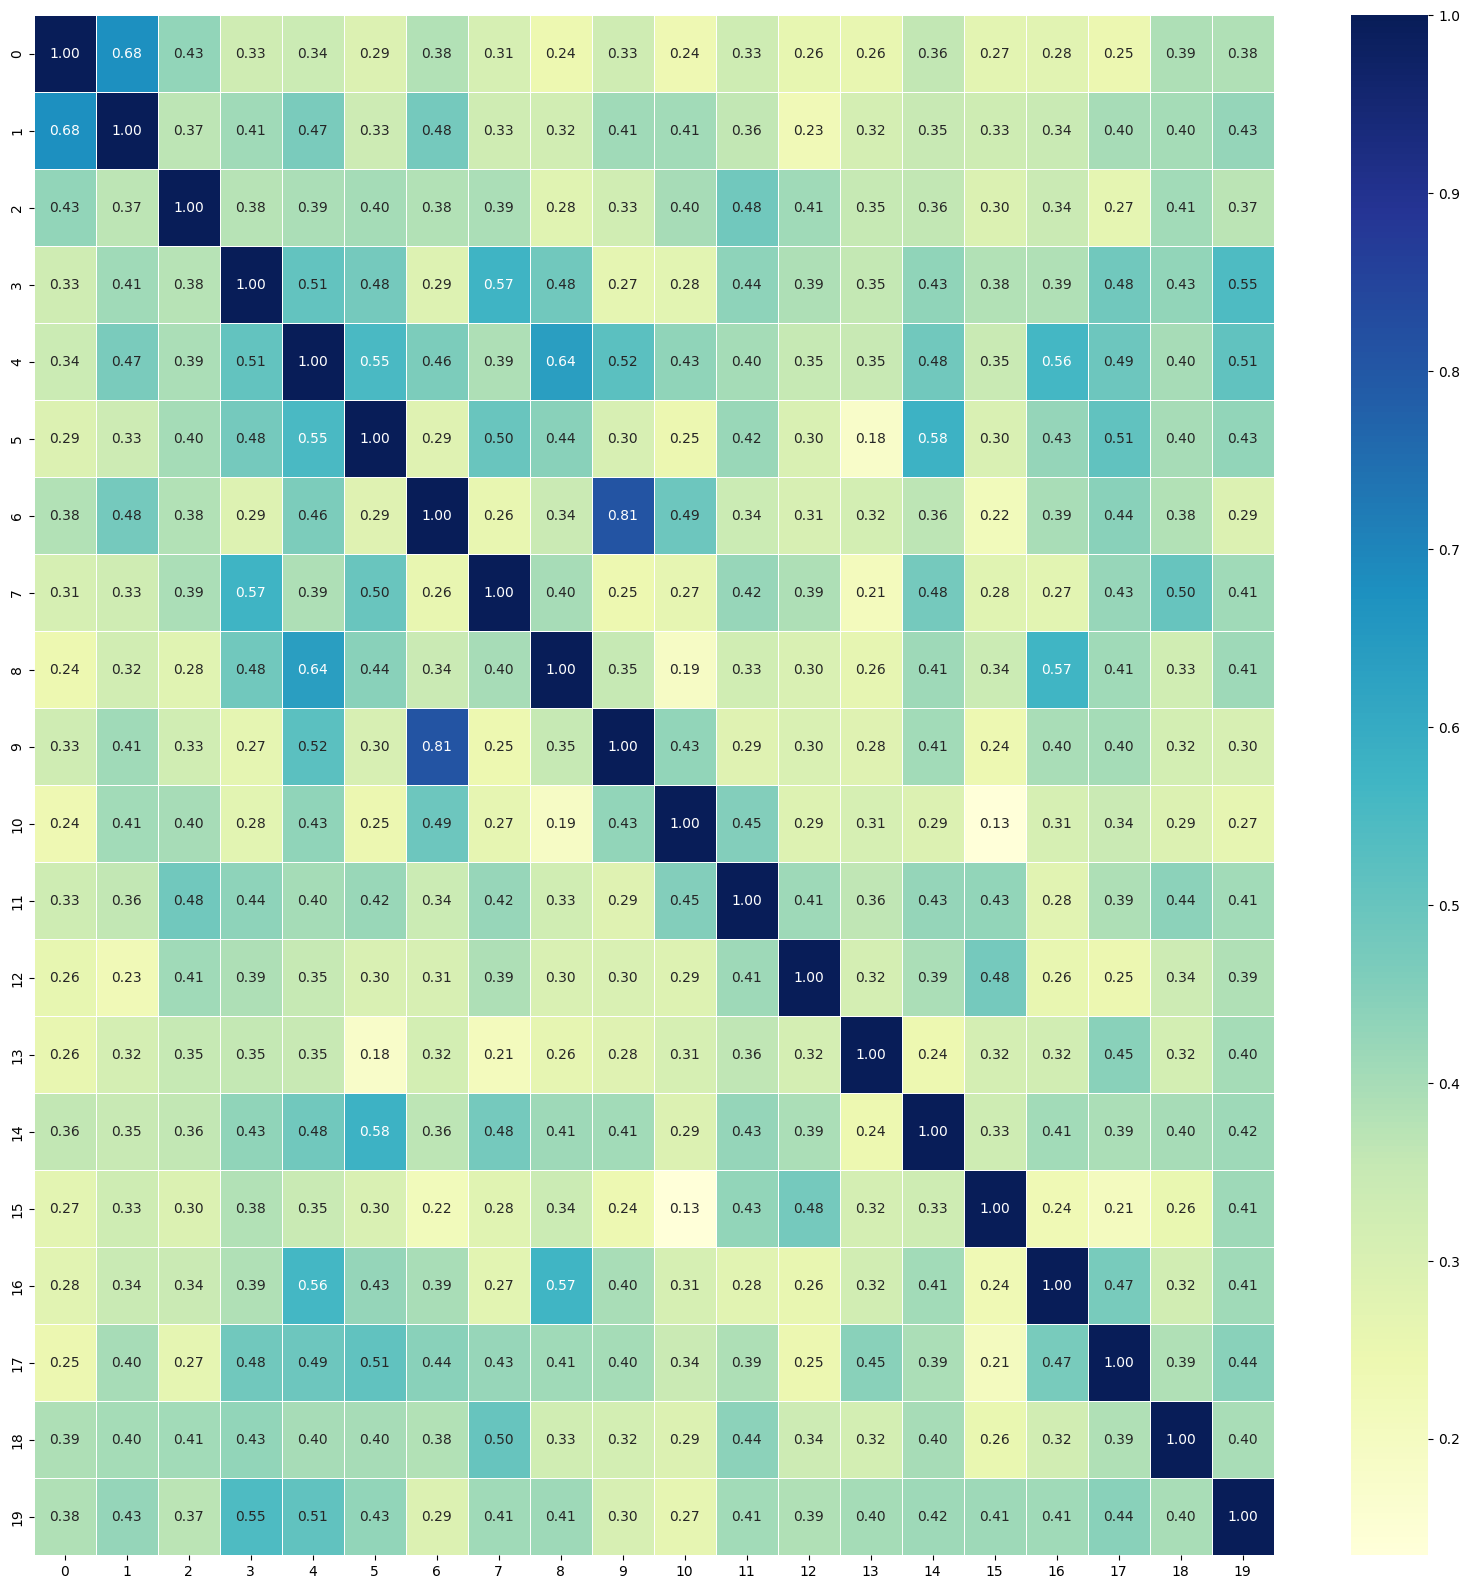

In [64]:
analyze_cos_similarity_fixed_docs(best_preds, [399, 566], runs=1, total_docs=20)

In [65]:
best_preds.loc[431, 'titles']

'RNA-sequencing of human pancreatic adenocarcinoma cancer tissues'

In [66]:
best_preds.loc[431, 'summaries']

'RNA-seq profiling was conducted on clinically-annotated human pancreatic adenocarcinoma cancer tissues'

In [67]:
best_preds.loc[431, 'species']

'human'

In [68]:
best_preds.loc[52, 'titles']

'Network-based integration of mRNA and miRNA profiles reveals new target genes involved in pancreatic cancer'

In [69]:
best_preds.loc[52, 'summaries']

'In this study, we used RNA-seq to investigate the transcriptomic (mRNA and miRNA) profiles of pancreatic cancer in 10 paired tumor and normal pancreatic samples from patients'

In [70]:
best_preds.loc[52, 'species']

'human'

In [71]:
best_preds

,ID_x,prob,log2(prob/prior),related_words,source,species,titles,summaries,documents,name,log2(auprc/prior),num_of_pos,pred_words,coef
494,GSE84697,0.496256,4.779568,"carcinoma,cell,clear,patient,renal,tumor",MONDO_0006295,human,Tumor immune microenvironment characterization...,"Tumor-infiltrating macrophages, NK cells, CD8+...",Tumor immune microenvironment characterization...,malignant urinary system neoplasm,5.076634,52,"renal,bladder,rcc,ccrcc,carcinoma,adrenocortic...","5.845,4.233,3.413,2.692,2.634,2.562,2.302,1.79..."
457,GSE81201,0.400241,4.469351,"bladder,tumor",MONDO_0006295,human,Bladder tumor sequencing,Prospective sequencing of a patient's bladder ...,Bladder tumor sequencingProspective sequencing...,malignant urinary system neoplasm,5.076634,52,"renal,bladder,rcc,ccrcc,carcinoma,adrenocortic...","5.845,4.233,3.413,2.692,2.634,2.562,2.302,1.79..."
227,GSE63183,0.393021,4.443090,"carcinoma,ccrcc,cell,clear,kidney,normal,renal...",MONDO_0006295,human,Loss of 5-hydroxymethylcytosine is linked to g...,Aberrant DNA methylation is common in cancer.T...,Loss of 5-hydroxymethylcytosine is linked to g...,malignant urinary system neoplasm,5.076634,52,"renal,bladder,rcc,ccrcc,carcinoma,adrenocortic...","5.845,4.233,3.413,2.692,2.634,2.562,2.302,1.79..."
254,GSE66036,0.970787,4.433218,"androgen,ar,cancer,lncap,men,prostate",MONDO_0002149,human,Genome wide analysis of androgen-regulated tra...,Prostate cancer is the most common cancer in m...,Genome wide analysis of androgen-regulated tra...,reproductive system cancer,4.323934,126,"prostate,ovarian,cancer,cervical,serous,endome...","9.338,7.471,5.061,4.273,2.001,1.866,1.803,1.43..."
566,GSE90459,0.937424,4.419073,"brain,cells,gbm,glioma,malignant,multiforme,su...",MONDO_0020665,mouse,RNA-seq analysis of mouse brain endothelial ce...,Glioblastoma multiforme (GBM) is a highly aggr...,RNA-seq analysis of mouse brain endothelial ce...,high grade malignant neoplasm,4.249418,123,"glioblastoma,glioma,gbm,gliomas,brain,grade,tu...","8.775,7.969,5.675,4.103,2.705,2.137,1.913,1.41..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396,GSE77352,0.137364,0.361560,"cancer,cells,identify,p53,regulated",MONDO_0002516,human,A RUNX2-mediated Epigenetic Regulation of the ...,The goal is to identify transcripts that are r...,A RUNX2-mediated Epigenetic Regulation of the ...,digestive system cancer,2.944177,283,"colorectal,hcc,cancer,pancreatic,colon,carcino...","7.137,6.025,5.879,5.386,4.260,4.022,3.995,3.97..."
333,GSE73398,0.130002,0.282086,"cancer,cancers,cells,cisregulatory,colorectal,...",MONDO_0002516,human,Fixed tissue ChIP-Seq (FiT-Seq) of archived cl...,Analysis of cancer epigenomes has revealed imp...,Fixed tissue ChIP-Seq (FiT-Seq) of archived cl...,digestive system cancer,2.944177,283,"colorectal,hcc,cancer,pancreatic,colon,carcino...","7.137,6.025,5.879,5.386,4.260,4.022,3.995,3.97..."
509,GSE85462,0.128620,0.266674,"cancer,genes,knockdown,rnaseq,tumor",MONDO_0002516,mouse,Escape from X-Inactivation Tumor Suppressor (E...,"In this manuscript, we described male-biased m...",Escape from X-Inactivation Tumor Suppressor (E...,digestive system cancer,2.944177,283,"colorectal,hcc,cancer,pancreatic,colon,carcino...","7.137,6.025,5.879,5.386,4.260,4.022,3.995,3.97..."
217,GSE62613,0.241646,0.227855,"cancer,cell,cells,doxorubicin,facilitates,gluc...",MONDO_0004993,human,Nuclear TIGAR mediates an epigenetic-metabolic...,Epigenetic and metabolic reprogrammings are im...,Nuclear TIGAR mediates an epigenetic-metabolic...,carcinoma,2.181929,501,"carcinoma,cancer,adenocarcinoma,hcc,lung,carci...","7.670,5.526,4.557,4.540,4.056,3.266,2.912,2.83..."
